Načteno 3278 bodů ve 2D prostoru.


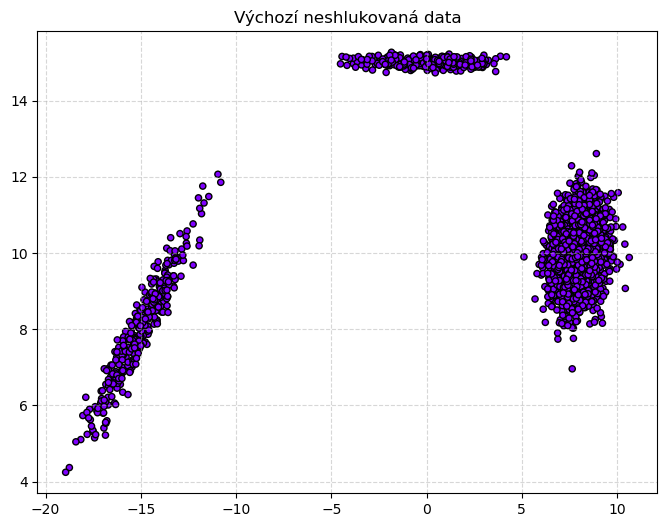

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import tvých vlastních modulů
from generic import load_data, plot_clusters
import clustering as cl

# Načtení dat ze souboru (změň cestu k souboru podle potřeby)
raw_data = load_data("data_shl.txt")

# Převod na numpy array: pro shlukování nás zajímají pouze první 2 sloupce (x, y)
X = np.array([[row[0], row[1]] for row in raw_data], dtype=np.float32)
# Původní třídy (pokud je chceme pro srovnání)
y_true = np.array([row[2] for row in raw_data])

print(f"Načteno {len(X)} bodů ve 2D prostoru.")

# Vykreslení výchozích (neoznačených) dat
plot_clusters(X, np.zeros(len(X)), "Výchozí neshlukovaná data")

In [2]:
print("--- Odhad počtu shluků ---")

# 1. Metoda shlukové hladiny
k_level = cl.clustering_level(X)
print(f"Metoda shlukové hladiny odhaduje: {k_level} shluků")

# 2. Metoda řetězové mapy
k_chain, _, _ = cl.chain_map(X)
print(f"Metoda řetězové mapy odhaduje:  {k_chain} shluků")

# 3. Metoda MAXIMIN
# q a start_node můžeš interaktivně měnit
k_maximin, _ = cl.maximin(X, q=0.5, start_node=0)
print(f"Metoda MAXIMIN odhaduje:        {k_maximin} shluků")

# Pro další fázi dělení si zvolíme jeden z odhadů (např. k_level)
K_TARGET = k_level
print(f"\nPro dělení dat do shluků budeme dále pracovat s K = {K_TARGET}")

--- Odhad počtu shluků ---
Metoda shlukové hladiny odhaduje: (np.int64(3), array([8.8764192e-04, 1.2292371e-03, 1.5066756e-03, ..., 8.1208187e-01,
       4.4586387e+00, 7.0122061e+00], shape=(3277,), dtype=float32), array([3.4159515e-04, 2.7743855e-04, 8.7777153e-06, ..., 1.0032535e-02,
       3.6465569e+00, 2.5535674e+00], shape=(3276,), dtype=float32), np.int64(3274)) shluků
Metoda řetězové mapy odhaduje:  3 shluků
Metoda MAXIMIN odhaduje:        3 shluků

Pro dělení dat do shluků budeme dále pracovat s K = (np.int64(3), array([8.8764192e-04, 1.2292371e-03, 1.5066756e-03, ..., 8.1208187e-01,
       4.4586387e+00, 7.0122061e+00], shape=(3277,), dtype=float32), array([3.4159515e-04, 2.7743855e-04, 8.7777153e-06, ..., 1.0032535e-02,
       3.6465569e+00, 2.5535674e+00], shape=(3276,), dtype=float32), np.int64(3274))


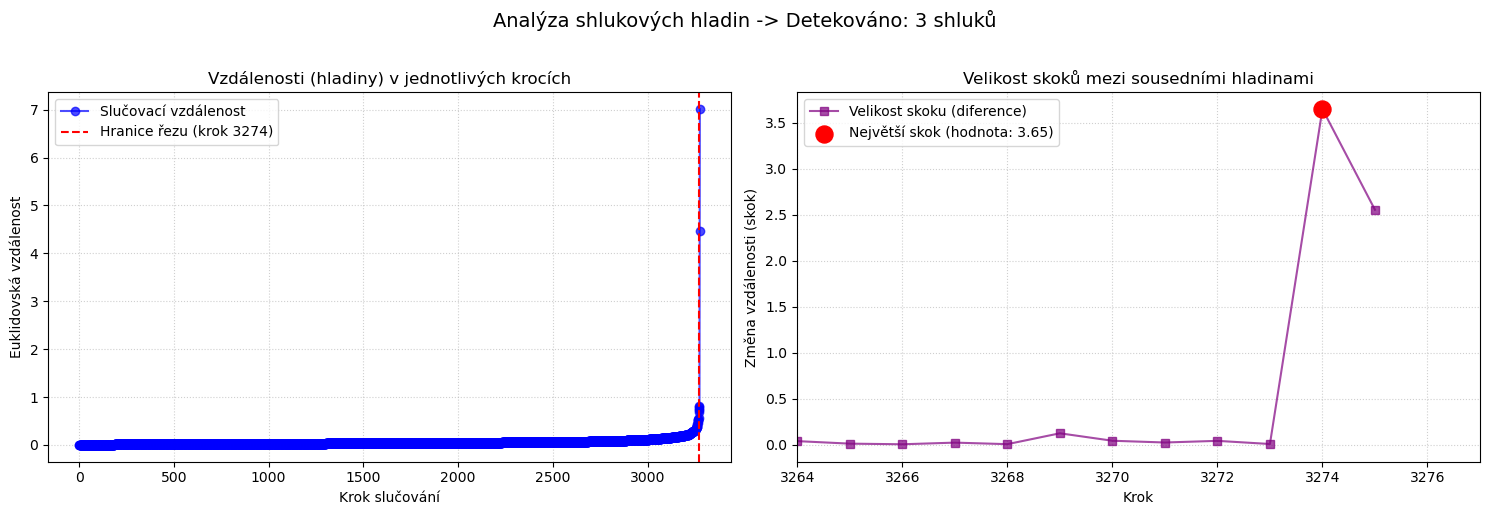

In [13]:
# Analýza Shlukových hladin
n_clusters, dists, jumps, cut_idx = cl.clustering_level(X)

# Vytvoříme dva grafy vedle sebe pro přehledné srovnání
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRAF 1: Vzdálenosti při slučování (Hladiny) ---
ax1.plot(dists, marker='o', color='blue', alpha=0.7, label='Slučovací vzdálenost')
# Červená čára značí krok, po kterém už bychom neměli slučovat
ax1.axvline(x=cut_idx, color='red', linestyle='--', label=f'Hranice řezu (krok {cut_idx})')
ax1.set_title("Vzdálenosti (hladiny) v jednotlivých krocích")
ax1.set_xlabel("Krok slučování")
ax1.set_ylabel("Euklidovská vzdálenost")
ax1.legend()
plt.xlim(cut_idx-10, len(dists))
ax1.grid(True, linestyle=":", alpha=0.6)

# --- GRAF 2: Skoky mezi hladinami (Derivace) ---
ax2.plot(jumps, marker='s', color='purple', alpha=0.7, label='Velikost skoku (diference)')
# Zvýrazníme největší skok, který rozhoduje o počtu shluků
ax2.scatter(cut_idx, jumps[cut_idx], color='red', s=150, zorder=5, 
            label=f'Největší skok (hodnota: {jumps[cut_idx]:.2f})')
ax2.set_title("Velikost skoků mezi sousedními hladinami")
ax2.set_xlabel("Krok")
ax2.set_ylabel("Změna vzdálenosti (skok)")
ax2.legend()
plt.xlim(cut_idx-10, len(dists))
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Analýza shlukových hladin -> Detekováno: {n_clusters} shluků", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

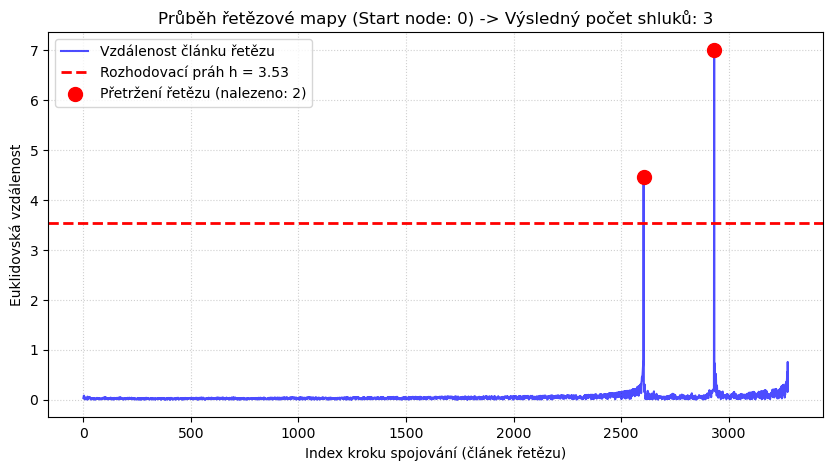

In [4]:
# Analýza Řetězové mapy
start_node = 0  # Můžeš zkusit změnit
n_clusters, dists, h = cl.chain_map(X, start_node=start_node)

plt.figure(figsize=(10, 5))
plt.plot(dists, label="Vzdálenost článku řetězu", color="blue", alpha=0.7)

# Vykreslení rozhodovací hranice H
plt.axhline(y=h, color="red", linestyle="--", linewidth=2, label=f"Rozhodovací práh h = {h:.2f}")

# Zvýraznění bodů, kde se řetězec přetrhl (vzdálenost > h)
break_indices = np.where(dists > h)[0]
plt.scatter(break_indices, dists[break_indices], color="red", s=100, zorder=5, 
            label=f"Přetržení řetězu (nalezeno: {len(break_indices)})")

plt.title(f"Průběh řetězové mapy (Start node: {start_node}) -> Výsledný počet shluků: {n_clusters}")
plt.xlabel("Index kroku spojování (článek řetězu)")
plt.ylabel("Euklidovská vzdálenost")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

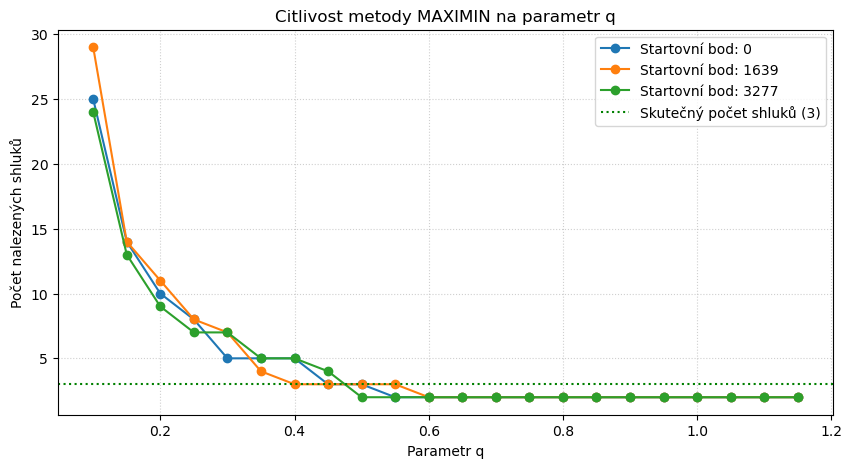

In [5]:
# Analýza citlivosti MAXIMIN
q_values = np.arange(0.1, 1.2, 0.05, dtype=np.float32)
starting_nodes = [0, len(X)//2, len(X)-1] # Tři různé počáteční body

plt.figure(figsize=(10, 5))

for start in starting_nodes:
    cluster_counts = []
    for q in q_values:
        n_clusters, _ = cl.maximin(X, q=q, start_node=start)
        cluster_counts.append(n_clusters)
    plt.plot(q_values, cluster_counts, marker='o', label=f"Startovní bod: {start}")

plt.title("Citlivost metody MAXIMIN na parametr q")
plt.xlabel("Parametr q")
plt.ylabel("Počet nalezených shluků")
plt.axhline(y=3, color="green", linestyle=":", label="Skutečný počet shluků (3)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

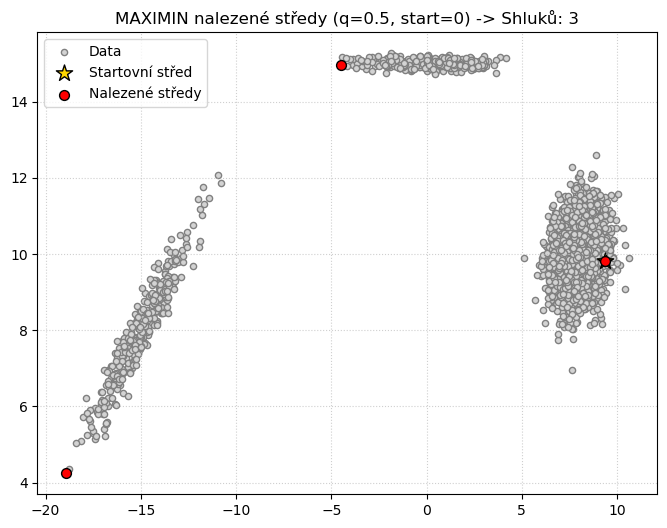

In [6]:
# Vykreslení středů z metody MAXIMIN
q_test = 0.5
start_test = 0

n_clusters, center_indices = cl.maximin(X, q=q_test, start_node=start_test)
centers = X[center_indices]

plt.figure(figsize=(8, 6))
# Všechny body vykreslíme šedě
plt.scatter(X[:, 0], X[:, 1], color="lightgray", edgecolors='gray', s=20, label="Data")

# Startovní bod zvýrazníme žlutě
plt.scatter(X[start_test, 0], X[start_test, 1], color="gold", edgecolors="k", s=150, marker="*", label="Startovní střed")

# Ostatní nalezené středy červeně
plt.scatter(centers[:, 0], centers[:, 1], color="red", edgecolors="k", s=50, marker="o", label="Nalezené středy")

plt.title(f"MAXIMIN nalezené středy (q={q_test}, start={start_test}) -> Shluků: {n_clusters}")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [7]:
# Nastavíme seed pro replikovatelnost náhodného výběru u standard_kmeans
np.random.seed(42)

# 1. Přímé dělení (Direct K-means)
centroids_dir, labels_dir, sse_dir = cl.direct_partitioning(X, K_TARGET)
plot_clusters(X, labels_dir, f"Přímé dělení (SSE: {sse_dir:.2f})", centroids_dir)

# 2. Nerovnoměrné binární dělení (Bisecting K-means)
centroids_bis, labels_bis, sse_bis = cl.bisecting_kmeans(X, K_TARGET)
plot_clusters(X, labels_bis, f"Binární dělení (SSE: {sse_bis:.2f})", centroids_bis)

print(f"Srovnání SSE kvality:")
print(f"-> Přímé dělení: {sse_dir:.2f}")
print(f"-> Binární dělení: {sse_bis:.2f}")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

In [ ]:
print("Optimalizuji výsledek přímého dělení...")
opt_centroids, opt_labels = cl.iterative_optimization(X, labels_dir, K_TARGET)

# Přepočet výsledného SSE po optimalizaci
opt_sse = cl.calculate_sse(X, opt_centroids, opt_labels)

plot_clusters(X, opt_labels, f"Po iterativní optimalizaci (SSE: {opt_sse:.2f})", opt_centroids)

print(f"\nZlepšení SSE po optimalizaci:")
print(f"Původní SSE: {sse_dir:.2f} -> Optimalizované SSE: {opt_sse:.2f}")

In [ ]:
# ----------------
# K-means
K_TARGET = 3  # Počet shluků, který nám vyšel z předchozích metod (MAXIMIN atd.)

# Přímé dělení
c_dir, l_dir, sse_dir = cl.direct_partitioning(X, K_TARGET)
print(f"Přímé dělení - SSE: {sse_dir:.2f}")
plot_clusters(X, l_dir, "Direct partitioning")

# Nerovnoměrné binární dělení
c_bis, l_bis, sse_bis = cl.bisecting_kmeans(X, K_TARGET)
print(f"Binární dělení - SSE: {sse_bis:.2f}")
plot_clusters(X, l_bis, "Bisecting k-means")

opt_centroids, opt_labels = cl.iterative_optimization(X, l_bis, 3)
print(f"Iterativní optimalizace: {'Optimalizováno' if (opt_labels-l_bis).any() else 'Beze změny'}")